In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
PROJECT_ROOT = Path.cwd().parent
out_dir = PROJECT_ROOT / "data" / "eval" / "results"

with open(out_dir / "predictions_detailed.json", "r", encoding="utf-8") as f:
    rows = json.load(f)

emb = np.load(out_dir / "embeddings_clip.npz")

n = len(rows)

print("out_dir:", out_dir)
print("n =", n)
print("arrays:", emb.files)

out_dir: /Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results
n = 20
arrays: ['image_embeddings', 'reference_short_ru_embeddings', 'predicted_caption_ru_embeddings', 'predicted_caption_en_embeddings', 'archive_prediction_embeddings']


In [3]:
sim_mats = {
    "image_vs_pred_en": cosine_similarity(
        emb["image_embeddings"],
        emb["predicted_caption_en_embeddings"],
    ),
    "image_vs_pred_ru": cosine_similarity(
        emb["image_embeddings"],
        emb["predicted_caption_ru_embeddings"],
    ),
    "image_vs_archive": cosine_similarity(
        emb["image_embeddings"],
        emb["archive_prediction_embeddings"],
    ),
    "image_vs_reference_ru": cosine_similarity(
        emb["image_embeddings"],
        emb["reference_short_ru_embeddings"],
    ),
}

for name, mat in sim_mats.items():
    print(name, mat.shape)

image_vs_pred_en (20, 20)
image_vs_pred_ru (20, 20)
image_vs_archive (20, 20)
image_vs_reference_ru (20, 20)


In [4]:
def summarize_similarity_matrix(mat: np.ndarray) -> dict:
    n = mat.shape[0]
    diag = np.diag(mat)

    offdiag_values = []
    best_offdiag = []
    best_match_idx = mat.argmax(axis=1)

    for i in range(n):
        row = mat[i].copy()
        offdiag_values.extend(np.delete(row, i))
        row_wo_diag = row.copy()
        row_wo_diag[i] = -np.inf
        best_offdiag.append(row_wo_diag.max())

    offdiag_values = np.array(offdiag_values, dtype=float)
    best_offdiag = np.array(best_offdiag, dtype=float)
    margin = diag - best_offdiag
    top1 = (best_match_idx == np.arange(n)).mean()

    return {
        "mean_diag": float(diag.mean()),
        "mean_offdiag": float(offdiag_values.mean()),
        "diag_minus_offdiag": float(diag.mean() - offdiag_values.mean()),
        "top1_accuracy": float(top1),
        "mean_margin": float(margin.mean()),
        "min_margin": float(margin.min()),
        "diag": diag,
        "best_offdiag": best_offdiag,
        "margin": margin,
        "best_match_idx": best_match_idx,
    }

In [5]:
summary_rows = []

summaries = {}
for name, mat in sim_mats.items():
    s = summarize_similarity_matrix(mat)
    summaries[name] = s
    summary_rows.append({
        "comparison": name,
        "mean_diag": s["mean_diag"],
        "mean_offdiag": s["mean_offdiag"],
        "diag_minus_offdiag": s["diag_minus_offdiag"],
        "top1_accuracy": s["top1_accuracy"],
        "mean_margin": s["mean_margin"],
        "min_margin": s["min_margin"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["top1_accuracy", "mean_margin", "mean_diag"],
    ascending=[False, False, False]
)

summary_df

,comparison,mean_diag,mean_offdiag,diag_minus_offdiag,top1_accuracy,mean_margin,min_margin
0,image_vs_pred_en,0.298303,0.195454,0.102849,0.75,0.025332,-0.077588
2,image_vs_archive,0.203248,0.198928,0.004320,0.10,-0.010409,-0.022948
3,image_vs_reference_ru,0.203750,0.202610,0.001139,0.05,-0.016693,-0.042004
1,image_vs_pred_ru,0.208288,0.204427,0.003861,0.05,-0.017071,-0.040768


In [6]:
def plot_similarity_heatmap(
    mat: np.ndarray,
    title: str,
    row_prefix: str = "I",
    col_prefix: str = "T",
    save_path: Path | None = None,
):
    n = mat.shape[0]
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(mat)

    ax.set_title(title)
    ax.set_xlabel("Text index")
    ax.set_ylabel("Image index")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"{col_prefix}{i+1}" for i in range(n)], rotation=45, ha="right")
    ax.set_yticklabels([f"{row_prefix}{i+1}" for i in range(n)])

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

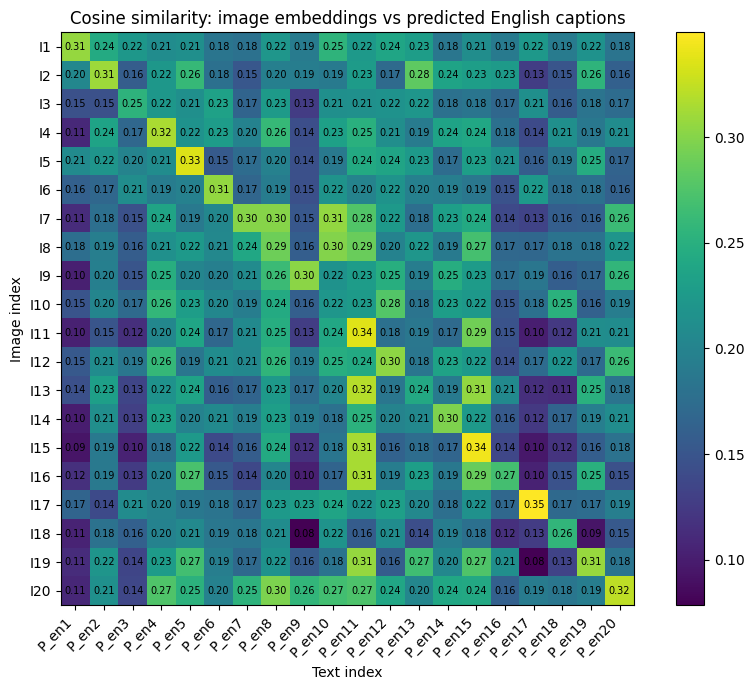

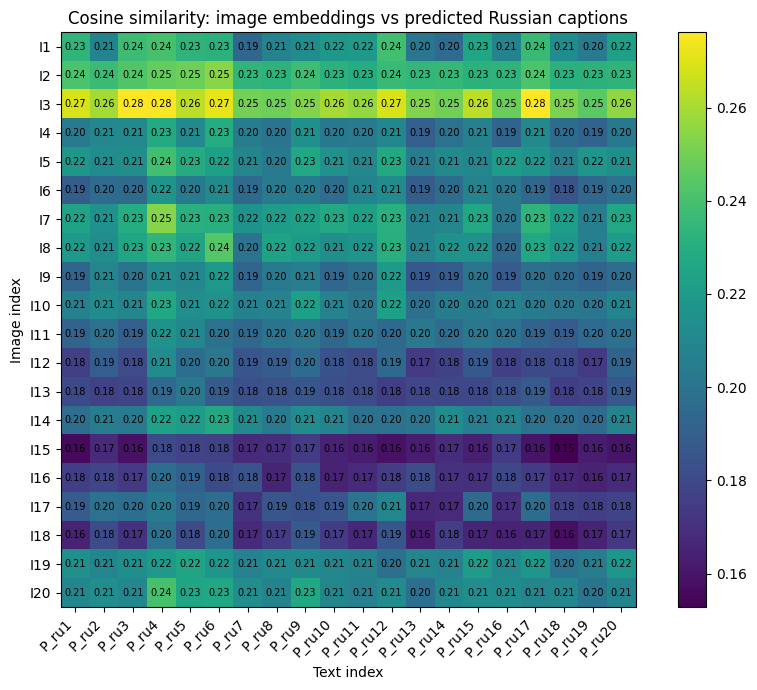

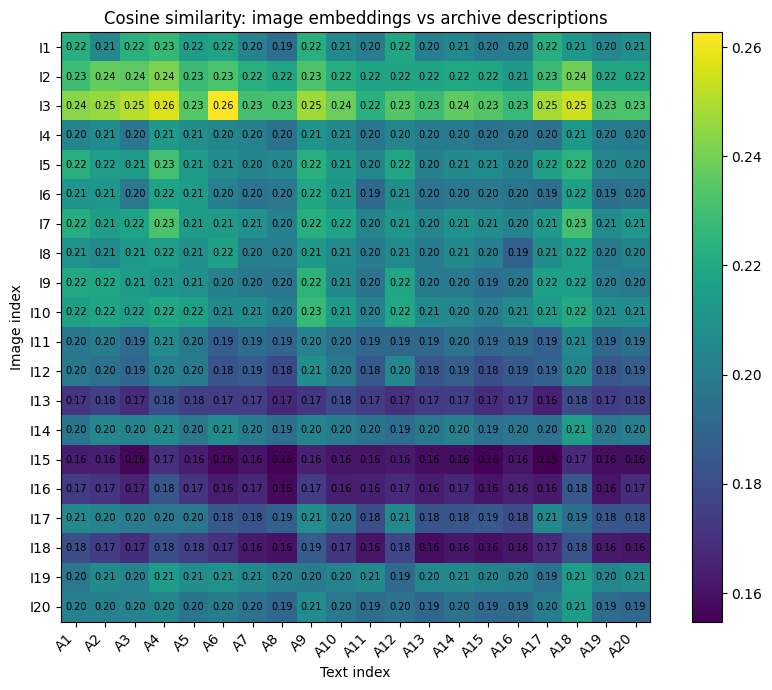

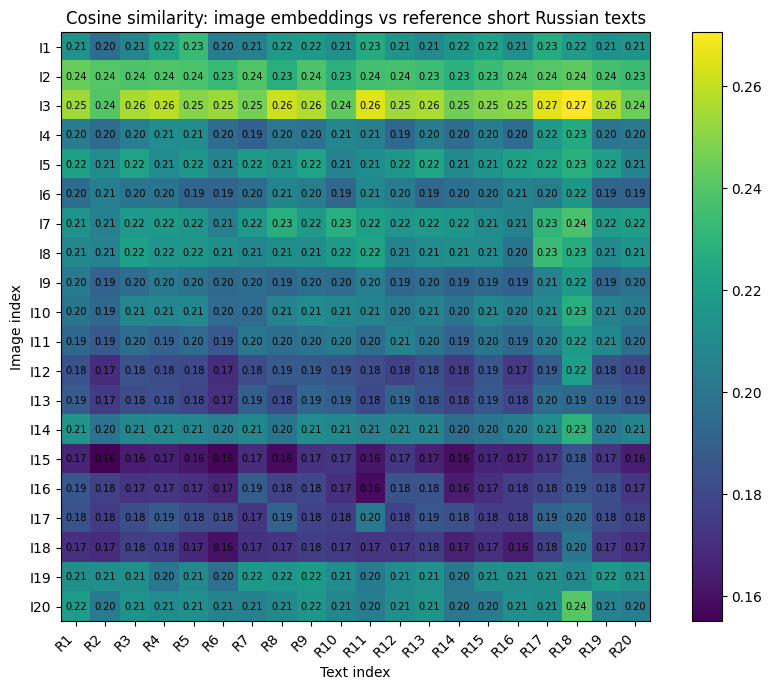

In [7]:
plot_similarity_heatmap(
    sim_mats["image_vs_pred_en"],
    "Cosine similarity: image embeddings vs predicted English captions",
    col_prefix="P_en",
    save_path=out_dir / "heatmap_image_vs_pred_en.png",
)

plot_similarity_heatmap(
    sim_mats["image_vs_pred_ru"],
    "Cosine similarity: image embeddings vs predicted Russian captions",
    col_prefix="P_ru",
    save_path=out_dir / "heatmap_image_vs_pred_ru.png",
)

plot_similarity_heatmap(
    sim_mats["image_vs_archive"],
    "Cosine similarity: image embeddings vs archive descriptions",
    col_prefix="A",
    save_path=out_dir / "heatmap_image_vs_archive.png",
)

plot_similarity_heatmap(
    sim_mats["image_vs_reference_ru"],
    "Cosine similarity: image embeddings vs reference short Russian texts",
    col_prefix="R",
    save_path=out_dir / "heatmap_image_vs_reference_ru.png",
)

In [8]:
diag_compare_df = pd.DataFrame({
    "sample_id": np.arange(1, n + 1),
    "image_name": [Path(r["image_path"]).name for r in rows],
    "pred_en": summaries["image_vs_pred_en"]["diag"],
    "pred_ru": summaries["image_vs_pred_ru"]["diag"],
    "archive": summaries["image_vs_archive"]["diag"],
    "reference_ru": summaries["image_vs_reference_ru"]["diag"],
})

diag_compare_df

,sample_id,image_name,pred_en,pred_ru,archive,reference_ru
0,1,postcard_1.jpg,0.306977,0.233572,0.222973,0.213303
1,2,postcard_2.jpg,0.309889,0.236716,0.237188,0.240103
2,3,postcard_3.jpg,0.253839,0.276126,0.250540,0.255429
3,4,postcard_4.jpg,0.315097,0.228273,0.212719,0.211467
4,5,postcard_5.jpg,0.334996,0.228705,0.214584,0.216296
5,6,postcard_6.jpg,0.305906,0.212057,0.201604,0.192897
6,7,postcard_7.jpg,0.300343,0.216027,0.209216,0.217367
7,8,postcard_8.jpg,0.289869,0.224126,0.200963,0.212753
8,9,postcard_9.jpg,0.302041,0.205768,0.224648,0.197359
9,10,postcard_10.jpg,0.220871,0.207412,0.214297,0.207837


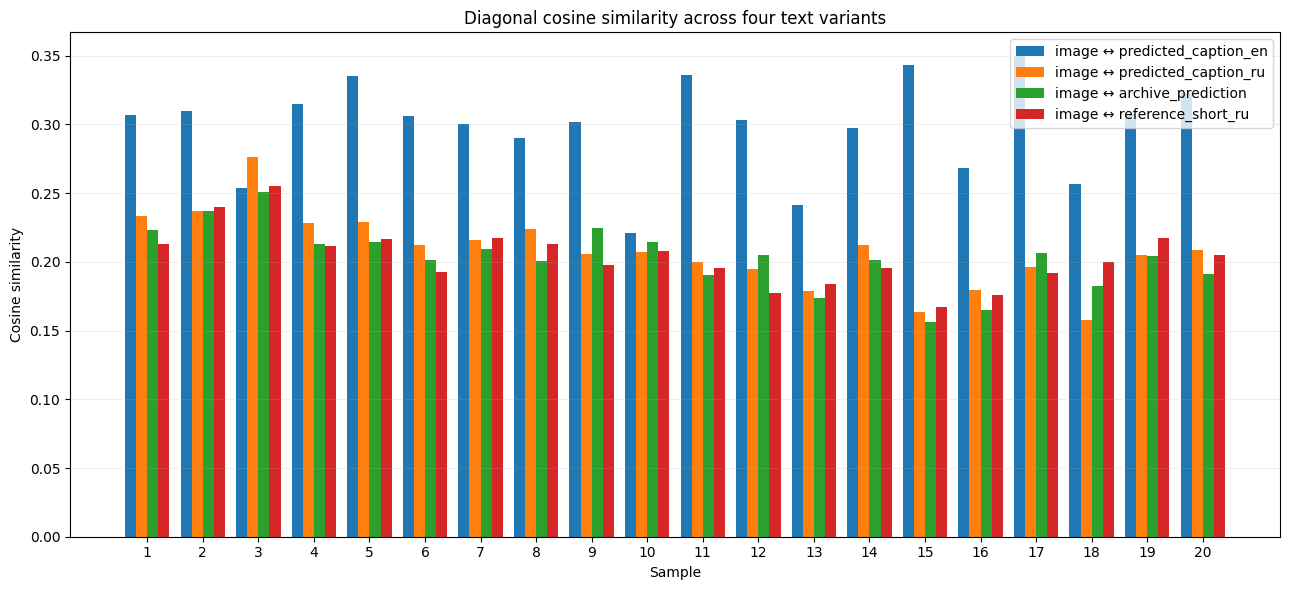

In [9]:
x = np.arange(n)
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - 1.5 * width, diag_compare_df["pred_en"], width, label="image ↔ predicted_caption_en")
ax.bar(x - 0.5 * width, diag_compare_df["pred_ru"], width, label="image ↔ predicted_caption_ru")
ax.bar(x + 0.5 * width, diag_compare_df["archive"], width, label="image ↔ archive_prediction")
ax.bar(x + 1.5 * width, diag_compare_df["reference_ru"], width, label="image ↔ reference_short_ru")

ax.set_title("Diagonal cosine similarity across four text variants")
ax.set_xlabel("Sample")
ax.set_ylabel("Cosine similarity")
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in range(n)])
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(out_dir / "bar_diag_four_text_variants.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
margin_summary_df = pd.DataFrame({
    "comparison": list(summaries.keys()),
    "mean_margin": [summaries[k]["mean_margin"] for k in summaries],
    "min_margin": [summaries[k]["min_margin"] for k in summaries],
    "top1_accuracy": [summaries[k]["top1_accuracy"] for k in summaries],
}).sort_values("mean_margin", ascending=False)

margin_summary_df

,comparison,mean_margin,min_margin,top1_accuracy
0,image_vs_pred_en,0.025332,-0.077588,0.75
2,image_vs_archive,-0.010409,-0.022948,0.10
3,image_vs_reference_ru,-0.016693,-0.042004,0.05
1,image_vs_pred_ru,-0.017071,-0.040768,0.05


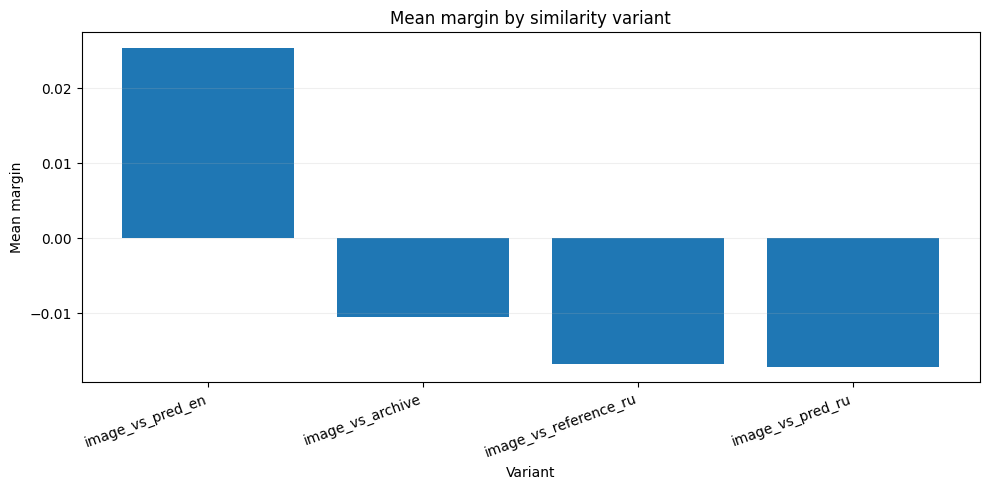

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(margin_summary_df["comparison"], margin_summary_df["mean_margin"])
ax.set_title("Mean margin by similarity variant")
ax.set_xlabel("Variant")
ax.set_ylabel("Mean margin")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "bar_mean_margin_four_variants.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
def build_match_table(name: str, mat: np.ndarray) -> pd.DataFrame:
    s = summaries[name]
    best_idx = s["best_match_idx"]
    diag = s["diag"]
    best_offdiag = s["best_offdiag"]
    margin = s["margin"]

    return pd.DataFrame({
        "sample_id": np.arange(1, n + 1),
        "image_name": [Path(r["image_path"]).name for r in rows],
        "best_text_idx": best_idx + 1,
        "is_correct_diagonal": best_idx == np.arange(n),
        "diag_similarity": diag,
        "best_offdiag_similarity": best_offdiag,
        "margin": margin,
    })

match_tables = {name: build_match_table(name, mat) for name, mat in sim_mats.items()}
match_tables["image_vs_pred_en"].head()

,sample_id,image_name,best_text_idx,is_correct_diagonal,diag_similarity,best_offdiag_similarity,margin
0,1,postcard_1.jpg,1,True,0.306977,0.254325,0.052651
1,2,postcard_2.jpg,2,True,0.309889,0.281929,0.027961
2,3,postcard_3.jpg,3,True,0.253839,0.234136,0.019703
3,4,postcard_4.jpg,4,True,0.315097,0.259613,0.055484
4,5,postcard_5.jpg,5,True,0.334996,0.246403,0.088593


In [13]:
clipscore_variants = pd.DataFrame({
    "variant": [
        "image ↔ predicted_caption_en",
        "image ↔ predicted_caption_ru",
        "image ↔ archive_prediction",
        "image ↔ reference_short_ru",
    ],
    "CLIPScore_mean": [
        np.diag(sim_mats["image_vs_pred_en"]).mean(),
        np.diag(sim_mats["image_vs_pred_ru"]).mean(),
        np.diag(sim_mats["image_vs_archive"]).mean(),
        np.diag(sim_mats["image_vs_reference_ru"]).mean(),
    ],
    "Top1_accuracy": [
        summaries["image_vs_pred_en"]["top1_accuracy"],
        summaries["image_vs_pred_ru"]["top1_accuracy"],
        summaries["image_vs_archive"]["top1_accuracy"],
        summaries["image_vs_reference_ru"]["top1_accuracy"],
    ],
    "Mean_margin": [
        summaries["image_vs_pred_en"]["mean_margin"],
        summaries["image_vs_pred_ru"]["mean_margin"],
        summaries["image_vs_archive"]["mean_margin"],
        summaries["image_vs_reference_ru"]["mean_margin"],
    ],
    "Mean_offdiag": [
        summaries["image_vs_pred_en"]["mean_offdiag"],
        summaries["image_vs_pred_ru"]["mean_offdiag"],
        summaries["image_vs_archive"]["mean_offdiag"],
        summaries["image_vs_reference_ru"]["mean_offdiag"],
    ],
})

clipscore_variants.sort_values("CLIPScore_mean", ascending=False)

,variant,CLIPScore_mean,Top1_accuracy,Mean_margin,Mean_offdiag
0,image ↔ predicted_caption_en,0.298303,0.75,0.025332,0.195454
1,image ↔ predicted_caption_ru,0.208288,0.05,-0.017071,0.204427
3,image ↔ reference_short_ru,0.203750,0.05,-0.016693,0.202610
2,image ↔ archive_prediction,0.203248,0.10,-0.010409,0.198928


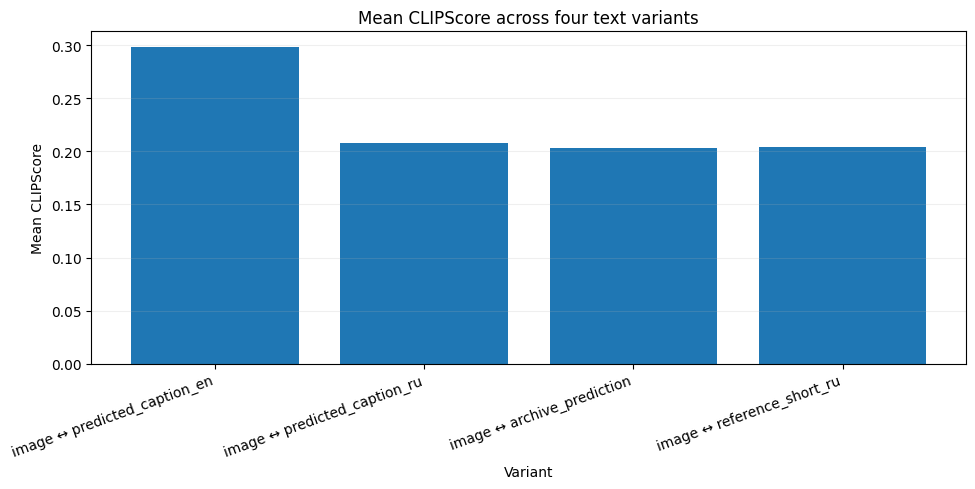

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(clipscore_variants["variant"], clipscore_variants["CLIPScore_mean"])

ax.set_title("Mean CLIPScore across four text variants")
ax.set_xlabel("Variant")
ax.set_ylabel("Mean CLIPScore")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "bar_clipscore_four_variants.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
per_sample_clipscores = pd.DataFrame({
    "sample_id": np.arange(1, n + 1),
    "image_name": [Path(r["image_path"]).name for r in rows],
    "clip_pred_en": np.diag(sim_mats["image_vs_pred_en"]),
    "clip_pred_ru": np.diag(sim_mats["image_vs_pred_ru"]),
    "clip_archive": np.diag(sim_mats["image_vs_archive"]),
    "clip_reference_ru": np.diag(sim_mats["image_vs_reference_ru"]),
})

per_sample_clipscores

,sample_id,image_name,clip_pred_en,clip_pred_ru,clip_archive,clip_reference_ru
0,1,postcard_1.jpg,0.306977,0.233572,0.222973,0.213303
1,2,postcard_2.jpg,0.309889,0.236716,0.237188,0.240103
2,3,postcard_3.jpg,0.253839,0.276126,0.250540,0.255429
3,4,postcard_4.jpg,0.315097,0.228273,0.212719,0.211467
4,5,postcard_5.jpg,0.334996,0.228705,0.214584,0.216296
5,6,postcard_6.jpg,0.305906,0.212057,0.201604,0.192897
6,7,postcard_7.jpg,0.300343,0.216027,0.209216,0.217367
7,8,postcard_8.jpg,0.289869,0.224126,0.200963,0.212753
8,9,postcard_9.jpg,0.302041,0.205768,0.224648,0.197359
9,10,postcard_10.jpg,0.220871,0.207412,0.214297,0.207837


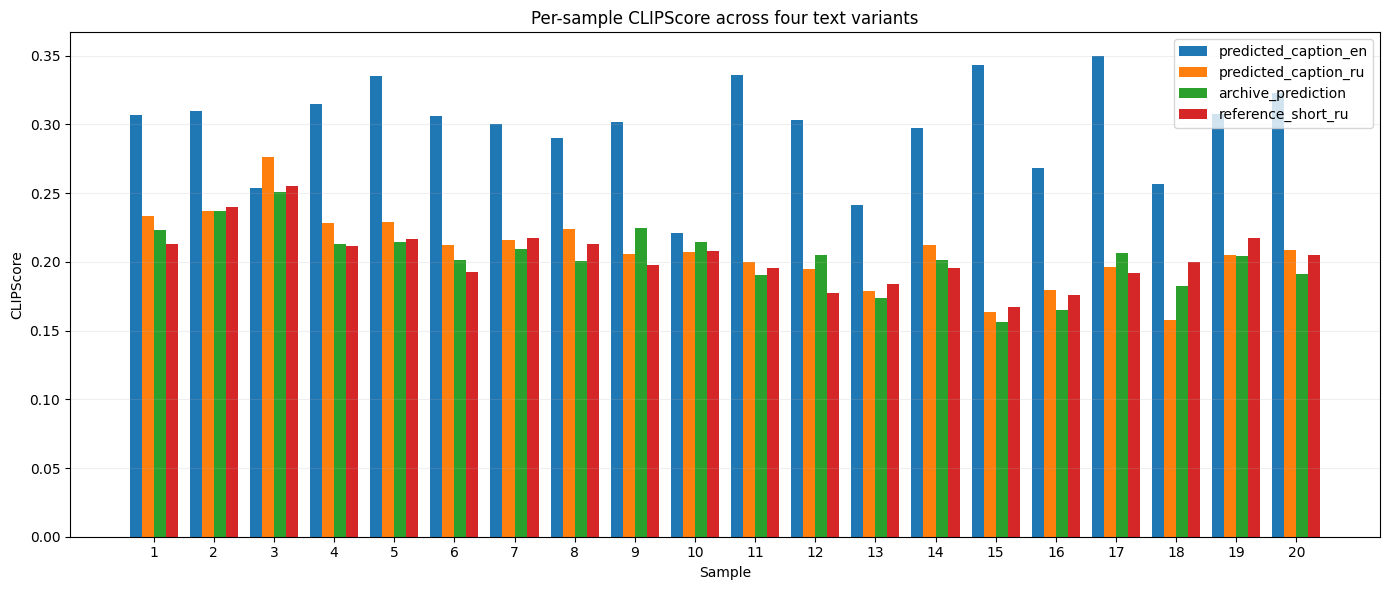

In [16]:
x = np.arange(n)
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - 1.5 * width, per_sample_clipscores["clip_pred_en"], width, label="predicted_caption_en")
ax.bar(x - 0.5 * width, per_sample_clipscores["clip_pred_ru"], width, label="predicted_caption_ru")
ax.bar(x + 0.5 * width, per_sample_clipscores["clip_archive"], width, label="archive_prediction")
ax.bar(x + 1.5 * width, per_sample_clipscores["clip_reference_ru"], width, label="reference_short_ru")

ax.set_title("Per-sample CLIPScore across four text variants")
ax.set_xlabel("Sample")
ax.set_ylabel("CLIPScore")
ax.set_xticks(x)
ax.set_xticklabels([str(i+1) for i in range(n)])
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(out_dir / "bar_per_sample_clipscores_four_variants.png", dpi=300, bbox_inches="tight")
plt.show()